Import libraries

In [ ]:
# libraries or whatev

from pathlib import Path
import geopandas as gpd
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import shapely

import scipy.stats as st
%matplotlib inline

Read location files, shapefiles for map

In [5]:
# List of counties to use 
countylist = ["063", "067", "081", "101", "119", "183"]

# Read location parquet file; create geodataframe; filter
read_loc = pd.read_parquet(Path.cwd()/'data/geospatial/unique_locations.pq')
locations = gpd.GeoDataFrame(data=read_loc, geometry=gpd.GeoSeries.from_wkb(read_loc['geometry']),crs='EPSG:32119')
locations=locations[locations['countyFIPS'].astype(str).isin(countylist)]

# Locations in Mecklenburg County
loc119 = locations[locations['countyFIPS']==119].to_crs('EPSG:4326')
loc119['sitename'] = {9:'Remount',11:'Friendship Park',10:'Garinger'}

# Read county shapefile; filter
county = gpd.read_file('data/geospatial/cb_2025_us_county_500k/cb_2025_us_county_500k.shp').to_crs('EPSG:4326')
nc_county = county[county['STATEFP']=='37']
my_county = nc_county[nc_county['COUNTYFP'].isin(countylist)]
mecklenburg = nc_county[nc_county['COUNTYFP'] == '119']

# Charlotte city center point
clt_point = shapely.Point([-80.843124,35.227085])

# Read roads shapefile; filter
roads = (gpd
         .read_file(Path.cwd()/'data/geospatial/roads/tl_2025_37_prisecroads.shp')
         .to_crs('EPSG:4326')
         .clip(mask=nc_county))
roads = roads[roads.geom_type != 'Point']

# Dictionary of road classifications
road_types = {'I': 'interstate',
              'U': 'ushwy',
              'S': 'nchwy'}

# Assign vars for different road types
roads_by_type = {name: roads[roads['RTTYP'] == code] 
                 for code, name in road_types.items()}
interstate, ushwy, nchwy = (roads_by_type['interstate'],
                            roads_by_type['ushwy'], 
                            roads_by_type['nchwy'])
interstate = roads[roads.RTTYP == 'I']

# Styles for roads
road_styles = {'I': 1.2, 'U': 0.9, 'S': 0.7}


Plot map of Charlotte sites

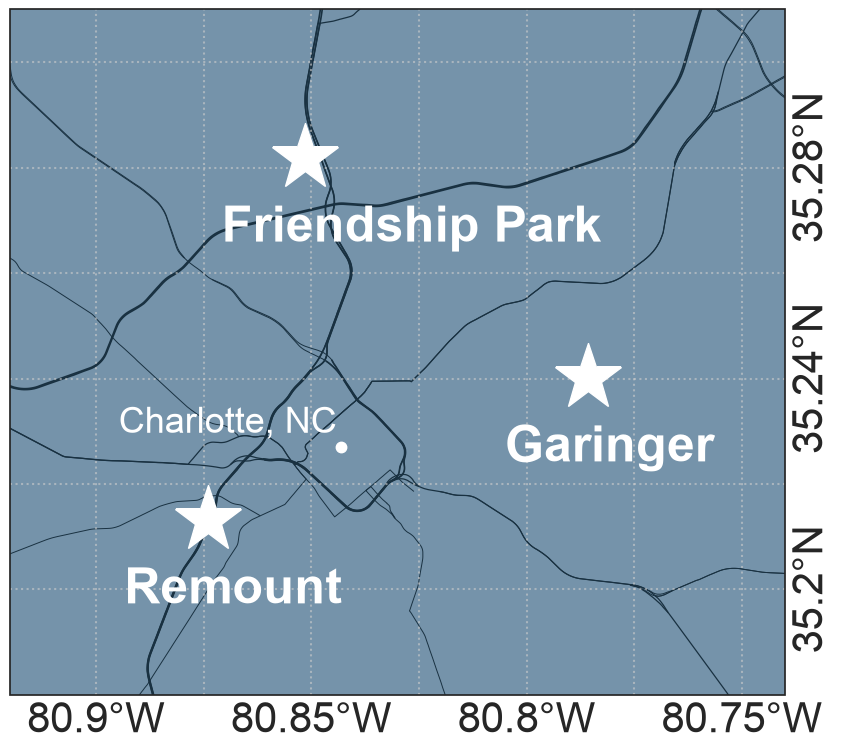

In [7]:
sns.set_theme(style='ticks', rc={'axes.grid': True, 'grid.linestyle': ':'})
fig=plt.figure(figsize=(10,10))
ax=plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor('#7593aa')#("#678ba3")#
map_domain = [-80.92, -80.74, 35.18, 35.31]
ax.set_extent(map_domain, crs=ccrs.PlateCarree())
# mecklenburg.plot(facecolor='#7593aa', edgecolor='none',ax=ax, zorder=1)

for rttyp, lw in road_styles.items():
    roads[roads['RTTYP'] == rttyp].plot(color="#193141", lw=lw, ax=ax, zorder=2)

mecklenburg.plot(facecolor='none', edgecolor='white', lw=1.3, ax=ax, zorder=3)

ax.plot(loc119.geometry.x,loc119.geometry.y,marker='*',color='white',ls='',markersize=50,zorder=5)

ax.plot(clt_point.x,clt_point.y,marker='.',color='white',markersize=15)
ax.annotate(text = 'Charlotte, NC', 
            xy=(clt_point.x,clt_point.y), 
            xytext=(-160,10),color='white', 
            size= 26,textcoords='offset points')
for x, y, label in zip(loc119.geometry.x, loc119.geometry.y, loc119['sitename']):
    ax.annotate(label, xy=(x, y), xytext=(-60,-60), 
                color='white', size= 36,weight='bold',
                textcoords='offset points')
gl=ax.gridlines(crs=ccrs.PlateCarree(),linewidth=1.5,alpha=0.6,linestyle=':',zorder=4)
gl.xlabel_style = dict(fontsize=30)
gl.ylabel_style = dict(fontsize=30,rotation=90)
gl.bottom_labels=True
gl.right_labels=True

fig.savefig('figs/mecklenburgctymap.svg',bbox_inches='tight')